### noise=5%

In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"../main_code/2d/Ex4.5")
sys.path.append(r"../main_code/2d")
import generate_data2,grid_cell,adaptive_int_fix1,visual,cal_S_grad,org_m,mea_2D,net_2D_fix2,S_valgrad,error_general_2D,main_fix1
CUDA_LAUNCH_BLOCKING=1

def f_circle(x,x_left,x_right,y_below,y_upper,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2)
    r_y = np.linalg.norm(x - center, axis=-1)
    # Apply the piecewise function
    f_y_values = np.where(r_y < r , 1.0, 0.0)
    return f_y_values

def f_rec(x,x_left,x_right,y_below,y_upper,center,r):
    cond= (x[:,0]>=x_left) & (x[:,0]<=x_right) & (x[:,1]>=y_below) & (x[:,1]<=y_upper)
    return cond*1

def ana_S(x,x_left,x_right,y_below,y_upper,center,r): #x为数据，a，b均为中心点
    return f_circle(x,x_left,x_right,y_below,y_upper,center,r)-f_rec(x,x_left,x_right,y_below,y_upper,center,r)


cuda:2


In [2]:
import copy
Nx,Ny=1,1
Ix,Iy=4,4  #x方向网格点
nx,ny=3,3  #每个网格x方向的高斯点
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89]
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max=-0.5,1.5,-0.5,1.5 #边界gamma处

num_batches_gauss=1
b_n=10
points_b=mea_2D.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) #在边界Γ处收集数据
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.2
center_true=np.array([0.71,0.5])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device=0
S_int_true1, F_mea_b1, F_mea_db_x11, F_mea_db_x21 = generate_data2.boundary_data_rec(kk, number_gene,points_b, f_rec, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
S_int_true2, F_mea_b2, F_mea_db_x12, F_mea_db_x22 = generate_data2.boundary_data_circle(kk, number_gene,points_b, f_circle, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
F_mea_b_05 = -F_mea_b1 + F_mea_b2
F_mea_db_x1_05 = -F_mea_db_x11 + F_mea_db_x12
F_mea_db_x2_05 = -F_mea_db_x21 + F_mea_db_x22
F_05=org_m.F(F_mea_b_05,F_mea_db_x1_05,F_mea_db_x2_05)

cells= grid_cell.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) #创造初始网格
initial_cells=copy.deepcopy(cells) #copy一份
R_m=20


In [3]:
M=1600
af="Tanh"   #先用tanh
R_m=20
cupy_device= 0
models = net_2D_fix2.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


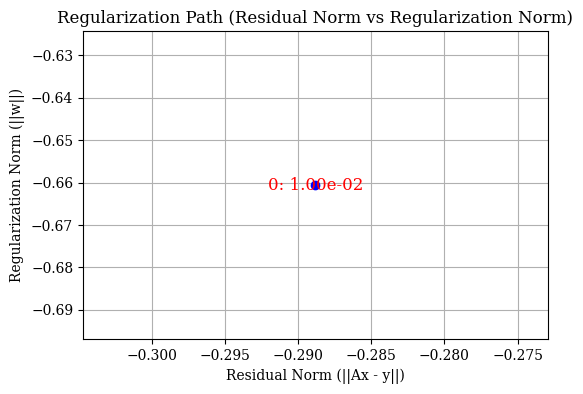

第 0 次迭代的train误差：
第 0 次迭代的泛化误差：


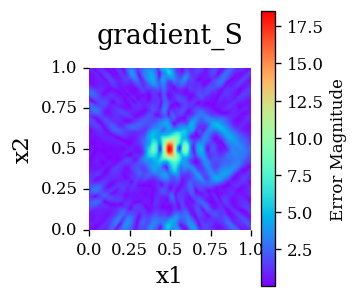

S_l_inf= 2.3512640716858226 S_L_2= 0.36090603111244024 S_l_2= 0.7990508235791502


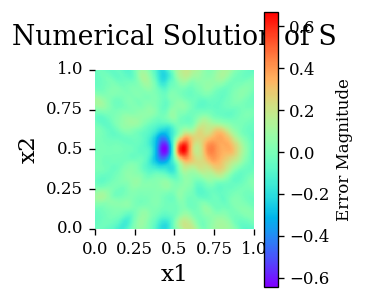

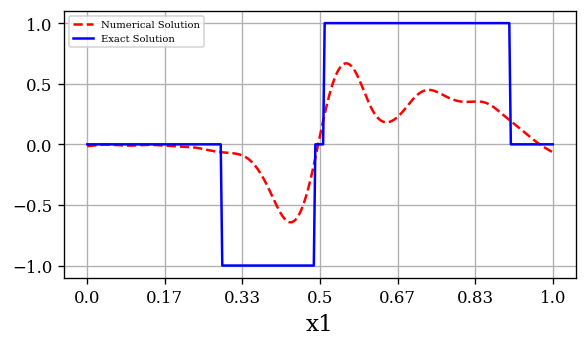

第 0 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


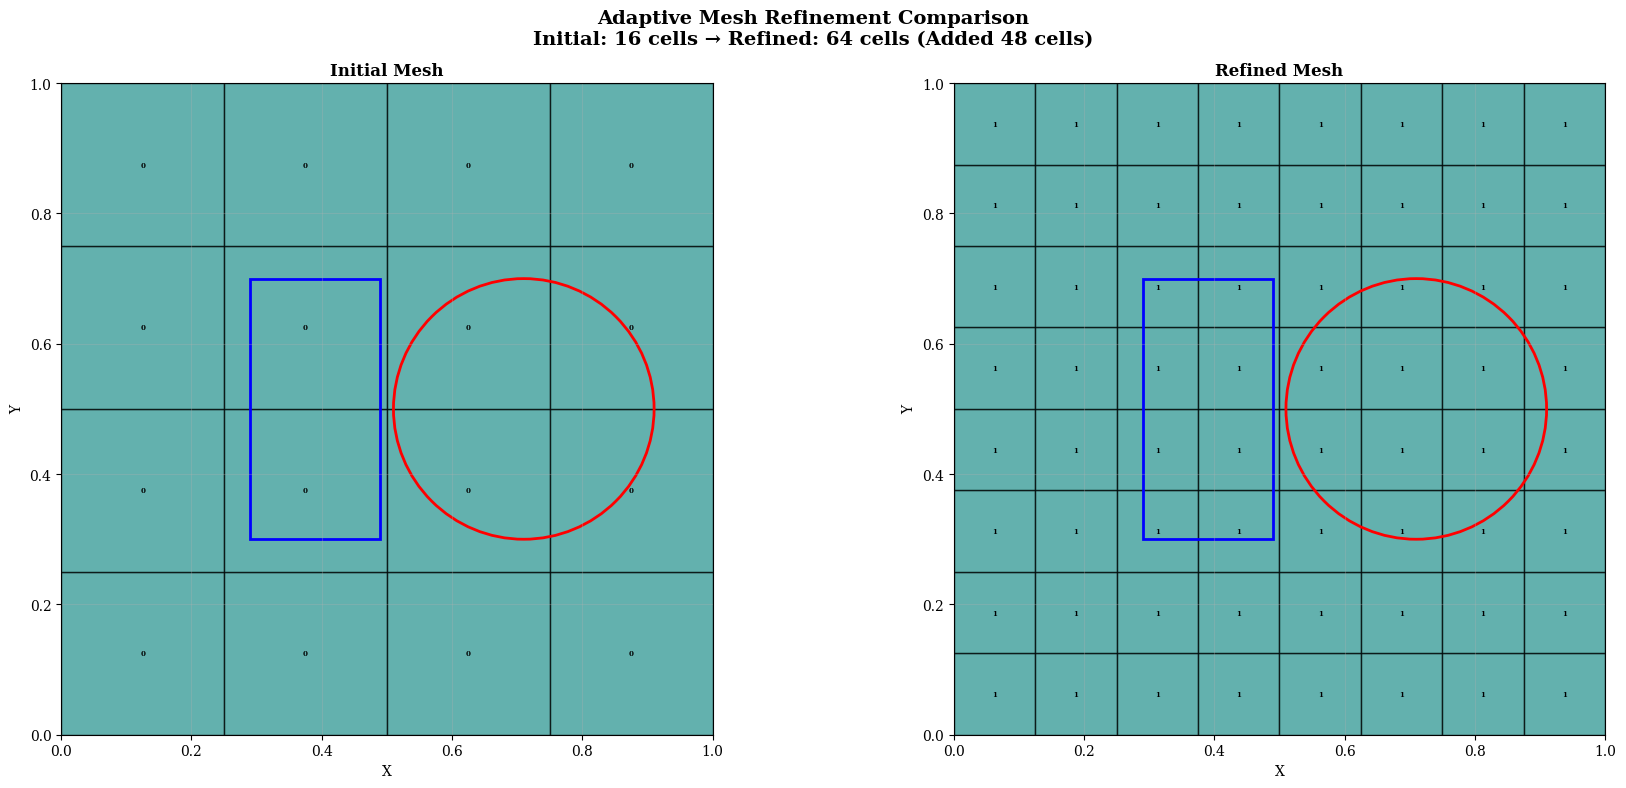

All visualizations completed!


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


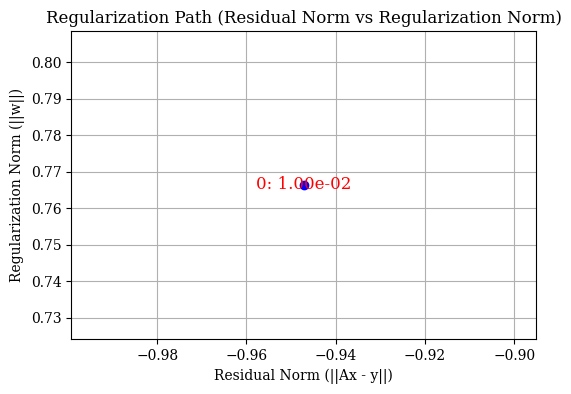

第 1 次迭代的train误差：
第 1 次迭代的泛化误差：


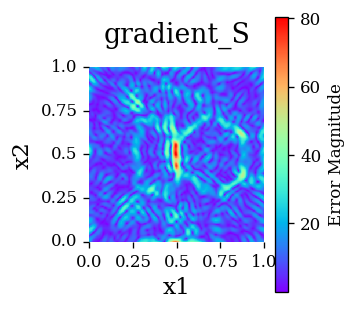

S_l_inf= 2.18482800914231 S_L_2= 0.2014331503502226 S_l_2= 0.44597571336607156


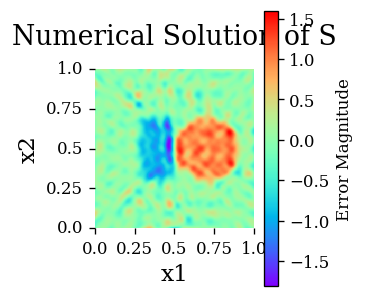

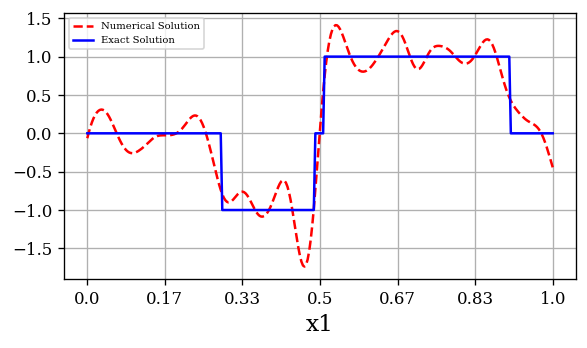

第 1 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


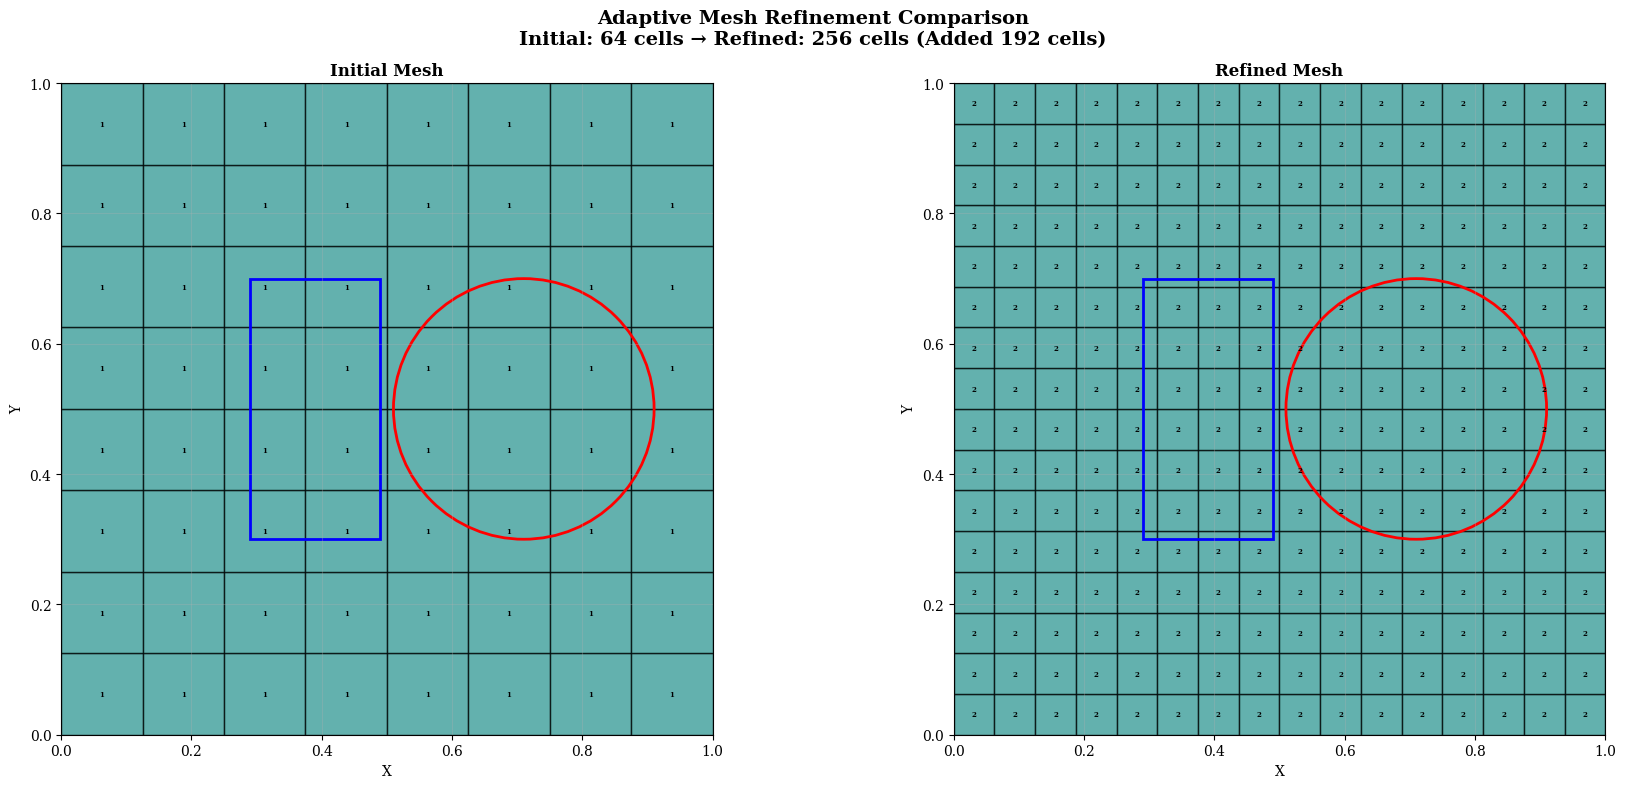

All visualizations completed!


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


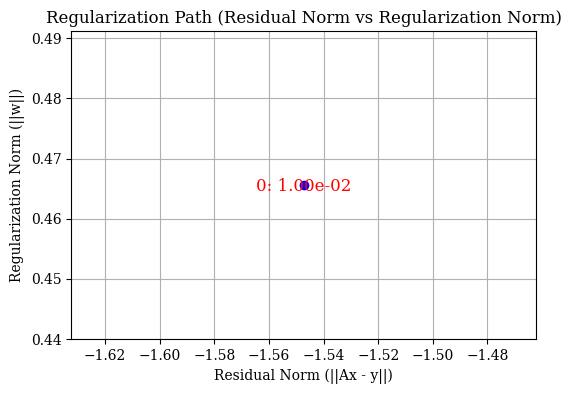

第 2 次迭代的train误差：
第 2 次迭代的泛化误差：


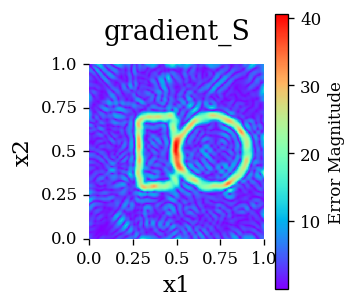

S_l_inf= 1.7443465366934345 S_L_2= 0.1057975396441468 S_l_2= 0.23423718058888746


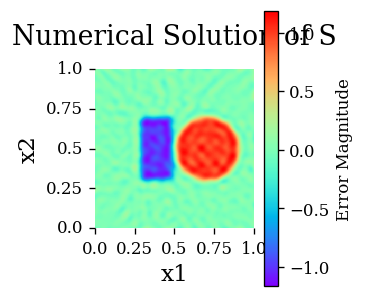

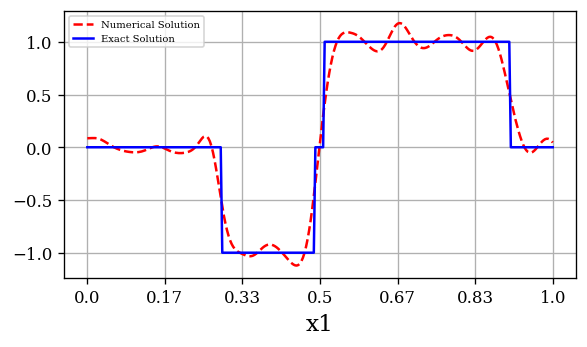

第 2 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


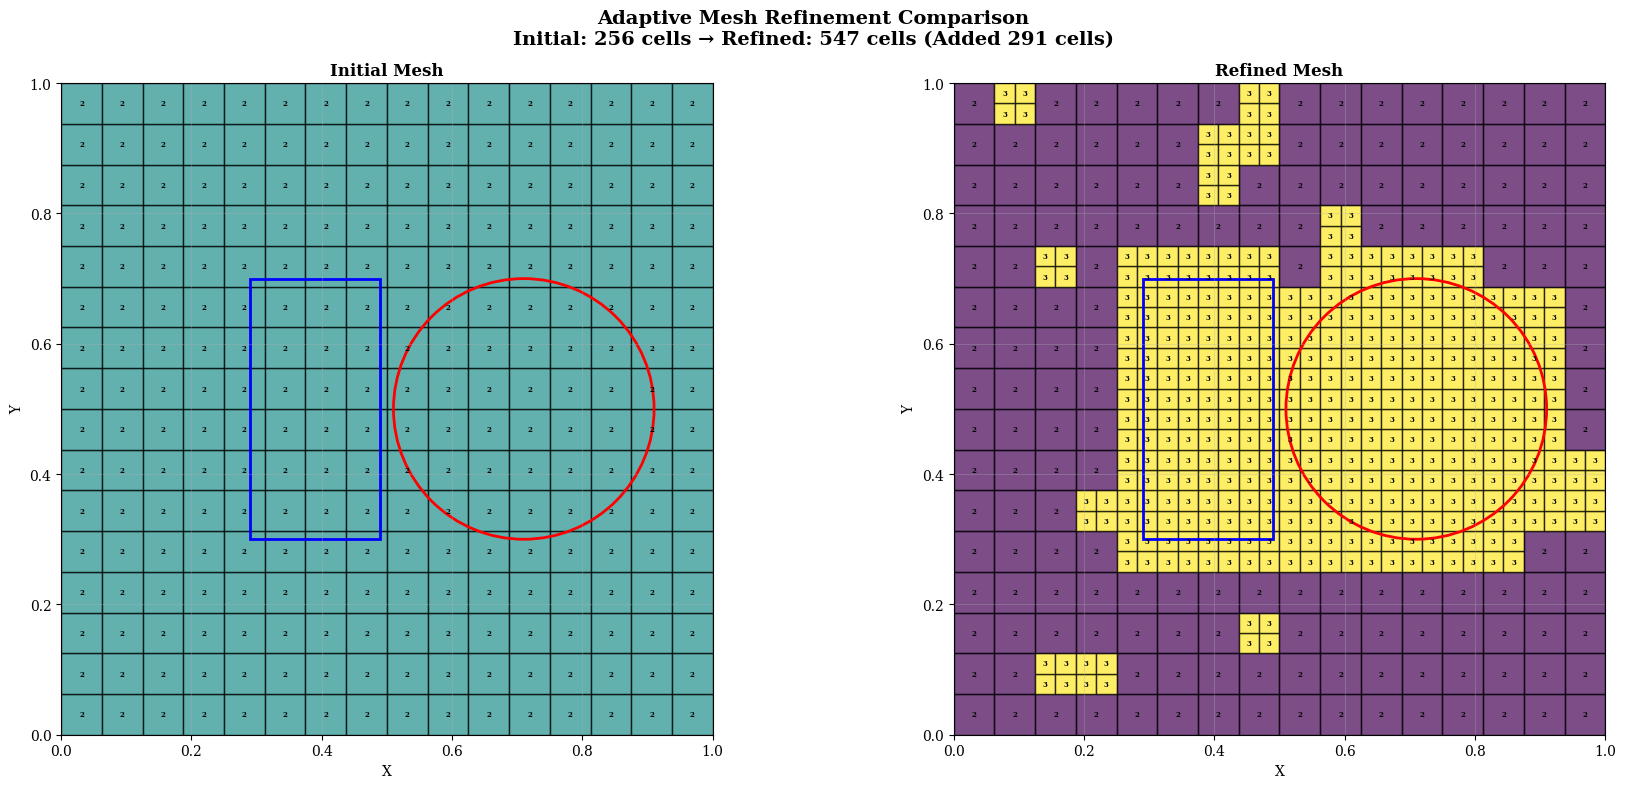

All visualizations completed!


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


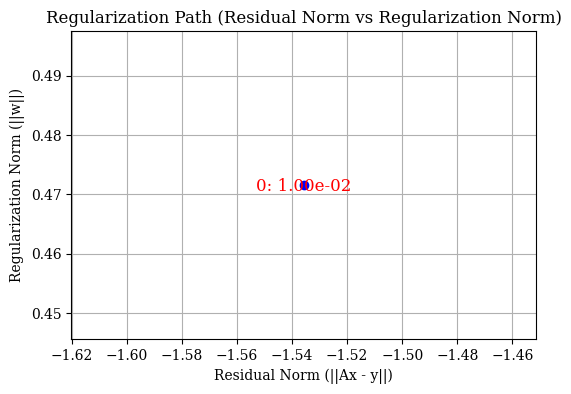

第 3 次迭代的train误差：
第 3 次迭代的泛化误差：


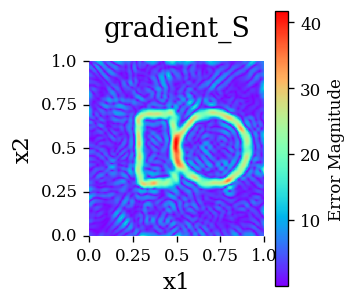

S_l_inf= 1.7690174051011185 S_L_2= 0.10614699870433653 S_l_2= 0.2350108876643583


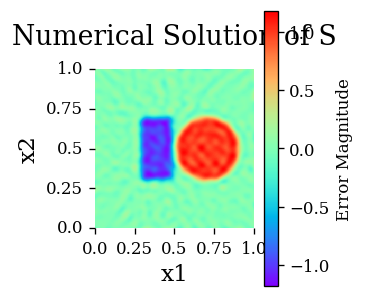

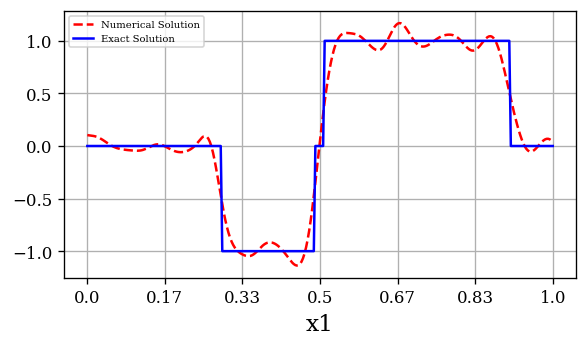

第 3 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


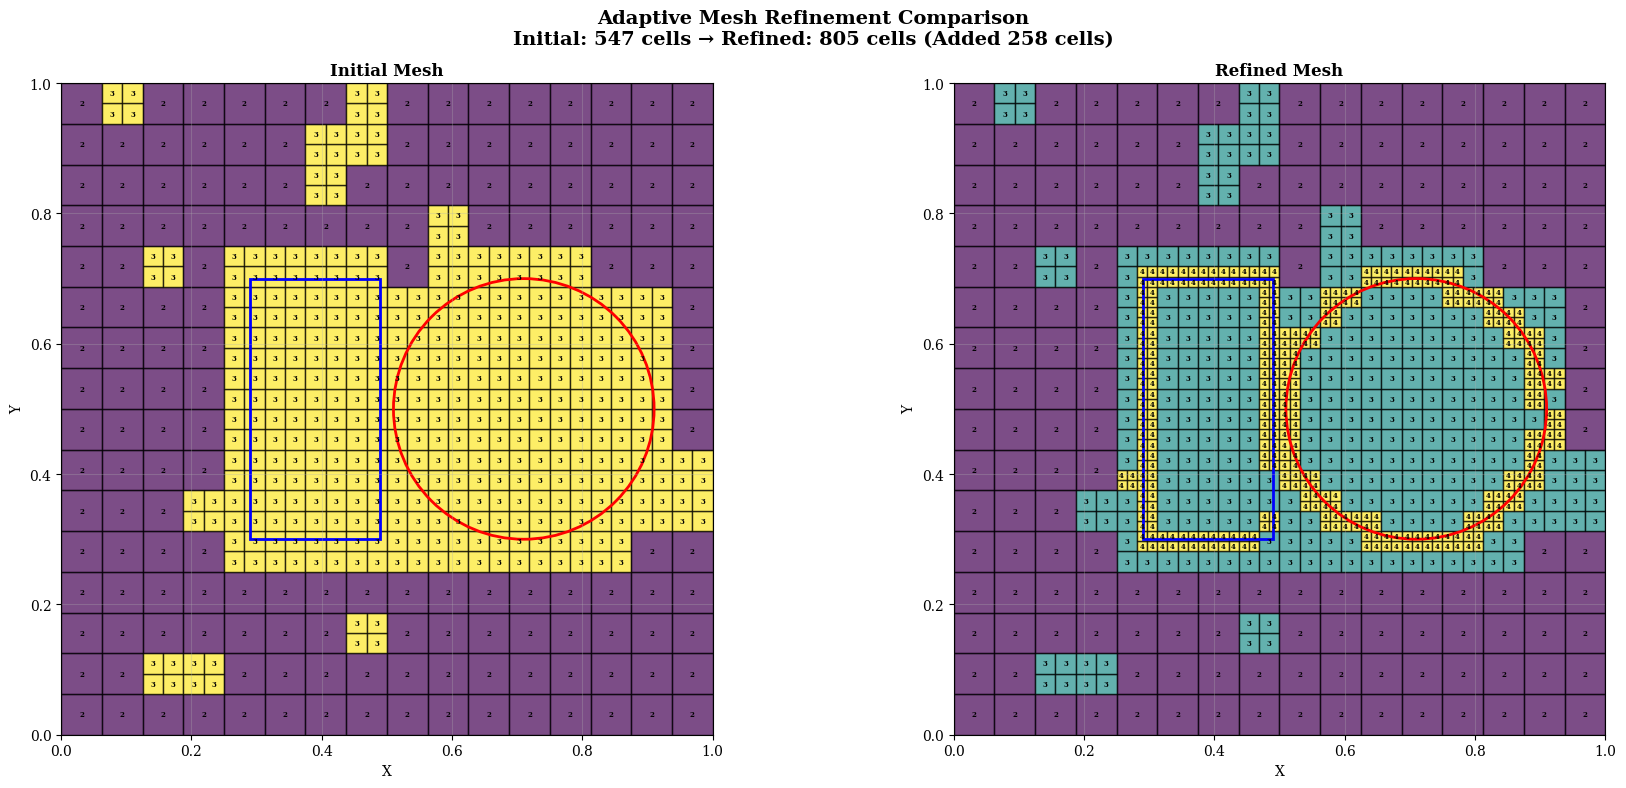

All visualizations completed!


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


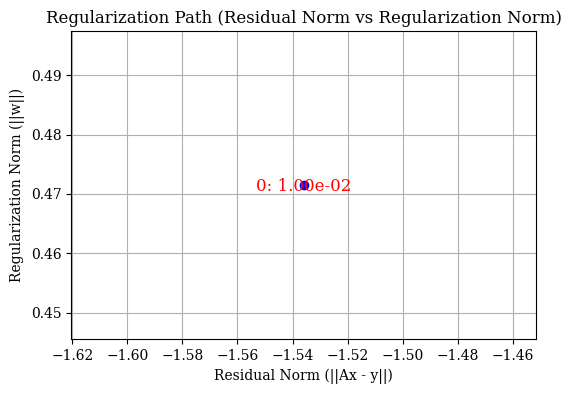

第 4 次迭代的train误差：
第 4 次迭代的泛化误差：


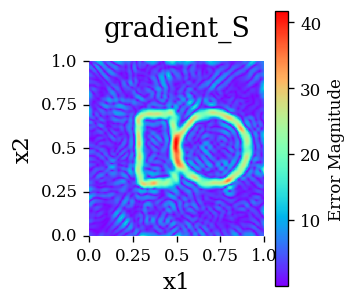

S_l_inf= 1.7692824573391461 S_L_2= 0.1061387944796855 S_l_2= 0.23499272340025876


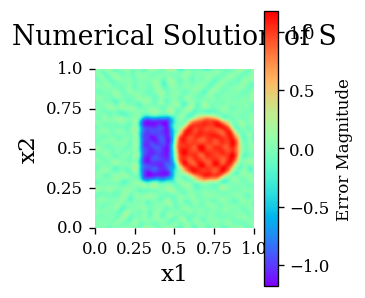

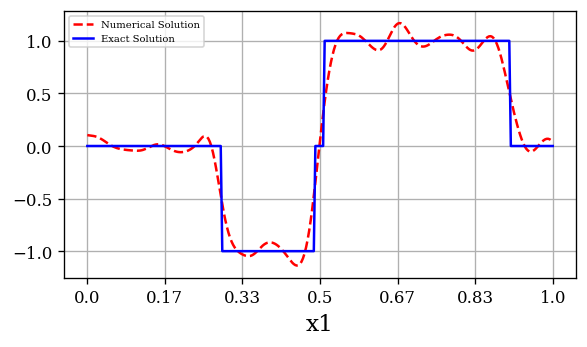

在第 4 次迭代结束


In [4]:
iter_int= 5
Ix,Iy=4,4  #x方向网格点
delta=10**(-3)
nx=3
lamb_regu=np.logspace(-2,-1,1)
Qx,Qy=150,150
max_level=4
current_maxiter=1
af="Tanh"
refine_threshold_S= [1/100] * 5
refine_threshold_grad=[1/100000] * 5
refine_threshold_noise=[1/300] * 5
Shape=[]
cells_store,refinement_stats_store,w_,point_number,S_num_store,g_store,g_S,S_l2=main_fix1.ada_int(iter_int,delta,cells,nx,models,M,af,Shape,kk,F_05,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,points_b,lamb_regu,Qx,Qy,device,cupy_device,refine_threshold_S,refine_threshold_grad,refine_threshold_noise,current_maxiter,max_level)

In [5]:
#保存cells_stores
import pickle

with open("./Noise/noise=5%/cells_store.pkl", "wb") as f:
    pickle.dump(cells_store, f)


Number of detected clusters: 2
CurvStd=0.282, PeakRatio=17.93 
Cluster 0: AR=1.91
  Res_Rect=0.028 vs Res_Ellip=0.136
  -> Winner: Rectangle
  CV of S_num: 0.254
Cluster 0: Lx=0.213, Ly=0.407, AR=1.91
  -> Decision: Rectangle (Sigmoid)
CurvStd=0.386, PeakRatio=8.73 
Cluster 1: AR=1.02
  Res_Rect=0.093 vs Res_Ellip=0.028
  -> Winner: Circle
  CV of S_num: 0.249
Cluster 1: Lx=0.393, Ly=0.400, AR=1.02
  -> Decision: Circle (Sigmoid)


/mnt/store/hxw-y23/MA-RFM-GIT/Ex4.5/./main_code/bound_detect.py:319: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


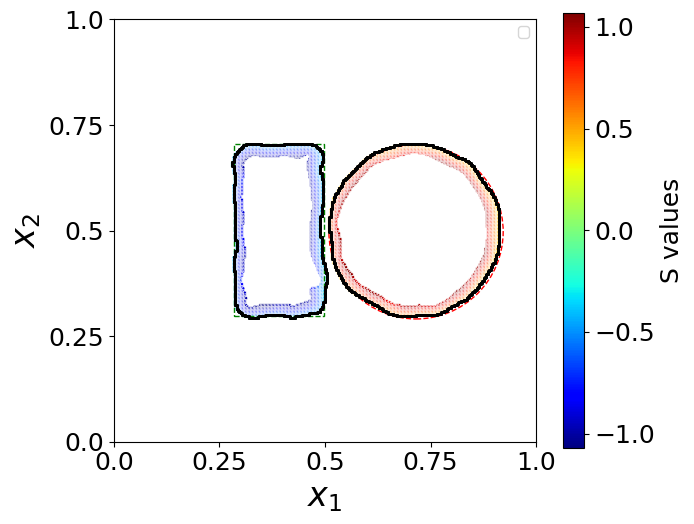

<Figure size 640x480 with 0 Axes>

In [6]:
import bound_detect
reload(bound_detect)
x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)
eps_cluster=0.01
mini_samples=20
para_abs=3
para_grad=3
results=bound_detect.detect_shape(g_S,X.T,Y.T,tau_x_min,tau_x_max,tau_y_min,tau_y_max,para_abs,para_grad,eps_cluster,mini_samples,S_num_store[-1],output_directory="./Noise/noise=5%", output_filename="plot.png")

In [7]:
results

[{'cluster_id': 0,
  'shape': 'Rectangle',
  'params': {'center': array([0.39129792, 0.50167732]),
   'W': 0.21333333333333337,
   'H': 0.4066666666666667},
  'profile': 'Sigmoid'},
 {'cluster_id': 1,
  'shape': 'Circle',
  'params': {'center': array([0.71556595, 0.4971211 ]),
   'radius': 0.20635865408130144},
  'profile': 'Sigmoid'}]

In [8]:
center1=results[0]['params']['center']
width=results[0]['params']['W']
height=results[0]['params']['H']
center2=results[1]['params']['center']
r=results[1]['params']['radius']


In [9]:
import net_2D_fix2

r_min=(1-0.1)*r
r_max=(1+0.05)*r
K_min=1000
K_max=20000
min_rec1,max_rec1,min_rec2,max_rec2=-center1[0]*(1+0.05),-center1[0]*(1-0.05),-center1[1]*(1+0.05),-center1[1]*(1-0.05)
min_c1,max_c1,min_c2,max_c2=-center2[0]*(1+0.05),-center2[0]*(1-0.05),-center2[1]*(1+0.05),-center2[1]*(1-0.05)
width_min,width_max=width*(1-0.1),width*(1+0.05)
height_min,height_max=height*(1-0.1),height*(1+0.05)
models0=models
#models0= net_2D_fix2.pre_define(Nx, Ny,1600,3,"Tanh",tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],K_min,K_max,[],device)
models1= net_2D_fix2.pre_define(Nx, Ny,2400,R_m,"sigmoid",tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_min,r_max,min_c1,max_c1,min_c2,max_c2,[],[],[],[],[],[],[],[],K_min,K_max,"circle",device)
models2= net_2D_fix2.pre_define(Nx, Ny,2400,R_m,"sigmoid",tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],min_rec1,max_rec1,min_rec2,max_rec2,width_min,width_max,height_min,height_max,[],[],[],[],K_min,K_max,"rec",device)
af="mix"
sum_mat,all_g_p1,all_g_n,cells_copy1=cal_S_grad.mat_assemble2(cells_store[-1],models0,models1,models2,"mix","circle","rec",kk,0,points_b,device,cupy_device)


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


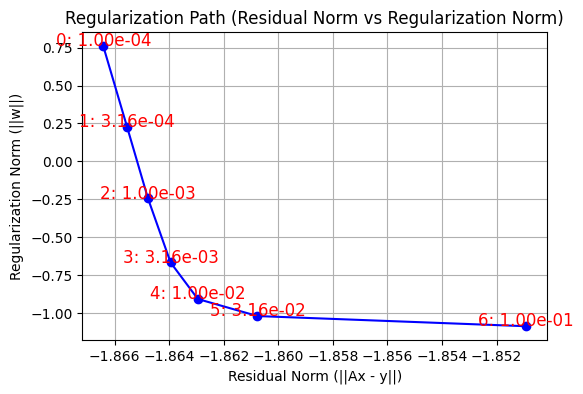

In [10]:
lamb_regu=np.logspace(-4,-1,7,endpoint=True)
res,reg_norm,w_store=org_m.L_curve(sum_mat,F_05,[],[],[],lamb_regu,"linear",device,cupy_device) #先进行求解q

lamb: 0.0001


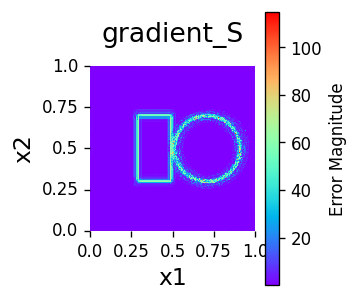

S_l_inf= 1.6369320049462779 S_L_2= 0.06742006108602816 S_l_2= 0.14926892512850135


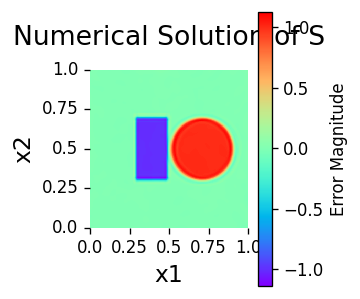

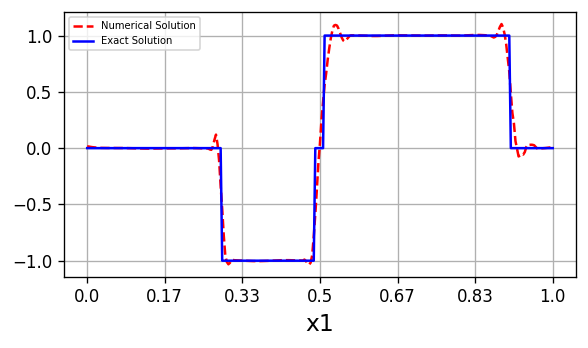

In [20]:
lamb=lamb_regu[4]**2
print('lamb:',lamb)
Qx,Qy=150,150
S_test_num,S_test_true,S_l_inf1,S_l_21,g_SS=error_general_2D.test(models0,models1,models2,[],Qx,Qy,w_store[:,4],"mix","circle","rec",True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,1,device)

In [21]:
import pickle

with open("./Noise/noise=5%/cells_store_last.pkl", "wb") as f:
    pickle.dump(cells_store[-1], f)

In [22]:
np.save(f"./Noise/noise=5%/S_num_1600+2400*2_{lamb}",S_test_num)
np.save("./Noise/noise=5%/all_mat",sum_mat)
np.save("./Noise/noise=5%/w_store",w_store)
np.save("./Noise/noise=5%/F_mea_b",F_mea_b_05)
np.save("./Noise/noise=5%/F_mea_db_x1",F_mea_db_x1_05)
np.save("./Noise/noise=5%/F_mea_db_x2",F_mea_db_x2_05)

In [23]:
# 保存 models1 模型
torch.save(models0,f"./Noise/noise=5%/models0_33_1600_{point_number[-1]}_{lamb}.pth")
torch.save(models1,f"./Noise/noise=5%/models1_33_2400_circle.pth")
torch.save(models2,f"./Noise/noise=5%/models2_33_2400_rec.pth")

In [24]:
np.save("./Noise/noise=5%/g_S1",g_SS)

In [25]:
parameters05 = {
    "I_grid":Ix,
    "gauss_n":nx,
    "number_gene":number_gene,
    "noise":eps,
    "k": kk,
    "M0": 1600,
    "M1": 2400,
    "M2": 2400,
    "Tanh_Rm":20,
    "Gauss_R_m": R_m,
    "refinement_stats_store":refinement_stats_store,
    "points_number_ada:":point_number,
    "r_min": r_min,
    "r_max": r_max,
    "min_rec1": min_rec1,
    "max_rec1": max_rec1,
    "min_rec2": min_rec1,
    "max_rec2": max_rec1,
    "width_min": width_min,
    "width_max": width_max,
    "height_min": height_min,
    "height_max": height_max,
    "min_circle1":min_c1,
    "max_circle1":max_c1,
    "min_circle2":min_c2,
    "max_circle2":max_c2,
    "K_min": K_min,
    "K_max": K_max,
}

In [26]:
import pickle # 导入 pickle 模块
output_pickle_file = "./Noise/noise=5%/parameters.pkl"
with open(output_pickle_file, 'wb') as f: # 'wb' for write binary
    pickle.dump(parameters05, f)

In [27]:
n_integral=len(cells_store[-1])*9
print('n_integral:',n_integral)
print('center1[0]:',center1)
print('center2[1]:',center2)
print('width:',width)
print('height:',height)
print('r:',r)
print('S_l2[-1]:',S_l2[-1])
print('lamb_regu:',lamb)
print('S_l21:',S_l_21)

n_integral: 7245
center1[0]: [0.39129792 0.50167732]
center2[1]: [0.71556595 0.4971211 ]
width: 0.21333333333333337
height: 0.4066666666666667
r: 0.20635865408130144
S_l2[-1]: 0.23499272340025876
lamb_regu: 0.0001
S_l21: 0.14926892512850135


In [28]:
g_S=np.load("./Noise/noise=5%/g_S.npy")
S_num_store=np.load("./Noise/noise=5%/S_num_store.npy")
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,1,0,1